# QuickCart Warehouse Inventory Stockout Risk

### Supervised Machine Learning Classification Project

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

In [ ]:
# Loading the Datasets

events = pd.read_csv("dim_events.csv")
skus = pd.read_csv("dim_skus.csv")
stores = pd.read_csv("dim_stores.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

In [ ]:
print("Events:", events.shape)
print("SKUs:", skus.shape)
print("Stores:", stores.shape)
print("Suppliers:", suppliers.shape)
print("Inventory:", inventory.shape)

Events: (30, 5)
SKUs: (60, 9)
Stores: (12, 8)
Suppliers: (15, 6)
Inventory: (21600, 16)


In [ ]:
print("Events columns:")
print(events.columns.tolist())

print("\nSKUs columns:")
print(skus.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

print("\nSuppliers columns:")
print(suppliers.columns.tolist())

print("\nInventory columns:")
print(inventory.columns.tolist())

Events columns:
['date', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other']

SKUs columns:
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

Stores columns:
['store_id', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders']

Suppliers columns:
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']

Inventory columns:
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk']


In [ ]:
print("===== EVENTS =====")
display(events.head())

print("\n===== SKUs =====")
display(skus.head())

print("\n===== STORES =====")
display(stores.head())

print("\n===== SUPPLIERS =====")
display(suppliers.head())

print("\n===== INVENTORY =====")
display(inventory.head())

===== EVENTS =====


,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,Regular Day,none,1.0,1.0
1,2026-10-02,Regular Day,none,1.0,1.0
2,2026-10-03,Regular Day,none,1.0,1.0
3,2026-10-04,Regular Day,none,1.0,1.0
4,2026-10-05,Regular Day,none,1.0,1.0



===== SKUs =====


,sku_id,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id
0,SKU001,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11
1,SKU002,Tomato 1kg,Fruits & Vegetables,148.76,3,Y,N,Medium,SUP08
2,SKU003,Onion 1kg,Fruits & Vegetables,66.13,3,Y,N,High,SUP01
3,SKU004,Potato 1kg,Fruits & Vegetables,51.99,5,Y,N,High,SUP01
4,SKU005,Apple 1kg,Fruits & Vegetables,145.91,5,Y,N,Medium,SUP08



===== STORES =====


,store_id,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders
0,ST01,Mumbai,Mumbai,Tier1,Large,2946,2023,580
1,ST02,Mumbai,Mumbai,Tier1,Small,1482,2024,235
2,ST03,Bengaluru,BENGALURU,Tier1,Large,3650,2022,552
3,ST04,Bengaluru,Bengaluru,Tier1,Large,4198,2025,524
4,ST05,Delhi,Delhi,Tier1,Medium,2220,2022,343



===== SUPPLIERS =====


,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
0,SUP01,Fresh Farms Co,Fruits & Vegetables,0.92,5,0.8
1,SUP02,Green Valley Distributors,Snacks,0.93,3,0.8
2,SUP03,Metro Dairy Supplies,Snacks,0.90,2,1.7
3,SUP04,Sunrise Agro Traders,"Beverages, Dairy",0.70,1,0.7
4,SUP05,National Snacks Ltd,Home Care,0.66,2,2.2



===== INVENTORY =====


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe


In [ ]:
print("===== EVENTS =====")
events.info()

print("\n===== SKUs =====")
skus.info()

print("\n===== STORES =====")
stores.info()

print("\n===== SUPPLIERS =====")
suppliers.info()

print("\n===== INVENTORY =====")
inventory.info()

===== EVENTS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       30 non-null     object 
 1   event_name                 30 non-null     object 
 2   event_type                 30 non-null     object 
 3   demand_multiplier_festive  30 non-null     float64
 4   demand_multiplier_other    30 non-null     float64
dtypes: float64(2), object(3)
memory usage: 1.3+ KB

===== SKUs =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sku_id            60 non-null     object 
 1   sku_name          60 non-null     object 
 2   category          60 non-null     object 
 3   unit_price_inr    60 non-null     float64
 4   shelf_life_days   60 non-nul

In [ ]:
print("===== EVENTS =====")
print(events.isnull().sum())

print("\n===== SKUs =====")
print(skus.isnull().sum())

print("\n===== STORES =====")
print(stores.isnull().sum())

print("\n===== SUPPLIERS =====")
print(suppliers.isnull().sum())

print("\n===== INVENTORY =====")
print(inventory.isnull().sum())

===== EVENTS =====
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

===== SKUs =====
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

===== STORES =====
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

===== SUPPLIERS =====
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

===== INVENTORY =====
date                           0
store_id                       0
sku_id                         0
sup

In [ ]:
print("Duplicate rows:")
print("----------------")
print("Events    :", events.duplicated().sum())
print("SKUs      :", skus.duplicated().sum())
print("Stores    :", stores.duplicated().sum())
print("Suppliers :", suppliers.duplicated().sum())
print("Inventory :", inventory.duplicated().sum())

Duplicate rows:
----------------
Events    : 0
SKUs      : 0
Stores    : 0
Suppliers : 0
Inventory : 0


##  Data Cleaning

In [ ]:
print("City values:")
print(stores["city_display"].unique())

City values:
['Mumbai' 'BENGALURU' 'Bengaluru' 'Delhi' 'Pune' 'hyderabad' 'Hyderabad'
 'Chennai']


In [ ]:
print("Clean city values:")
print(stores["city"].unique())

Clean city values:
['Mumbai' 'Bengaluru' 'Delhi' 'Pune' 'Hyderabad' 'Chennai']


In [ ]:
stores["city_display"] = stores["city_display"].str.title()

print(stores["city_display"].unique())

['Mumbai' 'Bengaluru' 'Delhi' 'Pune' 'Hyderabad' 'Chennai']


##  Handling Missing Supplier Reliability

In [ ]:
print("Missing reliability scores:")
print(suppliers["reliability_score"].isnull().sum())

print("\nReliability scores:")
print(suppliers["reliability_score"])

print(suppliers["reliability_score"].dtype)

median_reliability = suppliers["reliability_score"].median()

suppliers["reliability_score"] = suppliers["reliability_score"].fillna(median_reliability)

Missing reliability scores:
3

Reliability scores:
0     0.92
1     0.93
2     0.90
3     0.70
4     0.66
5      NaN
6     0.67
7     0.73
8     0.72
9     0.66
10    0.83
11    0.63
12    0.91
13     NaN
14     NaN
Name: reliability_score, dtype: float64
float64


In [ ]:
median_reliability = suppliers["reliability_score"].median()

suppliers["reliability_score"] = suppliers["reliability_score"].fillna(median_reliability)

In [ ]:
print("Missing values after cleaning:",
      suppliers["reliability_score"].isnull().sum())

Missing values after cleaning: 0


##  Date Validation

In [ ]:
events["date"] = pd.to_datetime(events["date"])
inventory["date"] = pd.to_datetime(inventory["date"])

In [ ]:
print("Events date range:")
print(events["date"].min(), "to", events["date"].max())

print("\nInventory date range:")
print(inventory["date"].min(), "to", inventory["date"].max())

Events date range:
2026-10-01 00:00:00 to 2026-10-30 00:00:00

Inventory date range:
2026-10-01 00:00:00 to 2026-10-30 00:00:00


In [ ]:
print("Unique event dates:", events["date"].nunique())
print("Unique inventory dates:", inventory["date"].nunique())

Unique event dates: 30
Unique inventory dates: 30


In [ ]:
print(events[events["event_type"] != "none"][[
    "date",
    "event_name",
    "event_type",
    "demand_multiplier_festive",
    "demand_multiplier_other"
]])

         date          event_name event_type  demand_multiplier_festive  \
10 2026-10-11  Weekend Flash Sale      promo                        1.3   
21 2026-10-22         Diwali Week   festival                        1.4   
22 2026-10-23         Diwali Week   festival                        1.7   
23 2026-10-24         Diwali Week   festival                        2.1   
24 2026-10-25         Diwali Week   festival                        2.6   
25 2026-10-26         Diwali Week   festival                        1.9   

    demand_multiplier_other  
10                    1.300  
21                    1.100  
22                    1.175  
23                    1.275  
24                    1.400  
25                    1.225  


##  Checking Keys and Relationships

In [ ]:
print("Unique Store IDs:", stores["store_id"].nunique())
print("Total Store Rows :", len(stores))

print("\nUnique SKU IDs:", skus["sku_id"].nunique())
print("Total SKU Rows :", len(skus))

print("\nUnique Supplier IDs:", suppliers["supplier_id"].nunique())
print("Total Supplier Rows :", len(suppliers))

Unique Store IDs: 12
Total Store Rows : 12

Unique SKU IDs: 60
Total SKU Rows : 60

Unique Supplier IDs: 15
Total Supplier Rows : 15


In [ ]:
print("Invalid store IDs:",
      (~inventory["store_id"].isin(stores["store_id"])).sum())

print("Invalid SKU IDs:",
      (~inventory["sku_id"].isin(skus["sku_id"])).sum())

print("Invalid supplier IDs:",
      (~inventory["supplier_id"].isin(suppliers["supplier_id"])).sum())

Invalid store IDs: 0
Invalid SKU IDs: 0
Invalid supplier IDs: 0


##  Merging the Datasets

In [ ]:
df = inventory.merge(
    stores,
    on="store_id",
    how="left"
)
print(df.shape)

(21600, 23)


In [ ]:
df = df.merge(
    skus,
    on="sku_id",
    how="left"
)
print(df.shape)

(21600, 31)


In [ ]:
df = df.merge(
    suppliers,
    left_on="supplier_id_y",
    right_on="supplier_id",
    how="left"
)
print(df.shape)

(21600, 37)


In [ ]:
df = df.merge(
    events,
    on="date",
    how="left"
)
print(df.shape)

(21600, 41)


In [ ]:
print("Final dataset shape:", df.shape)
print("Final dataset rows:", len(df))

Final dataset shape: (21600, 41)
Final dataset rows: 21600


## Verifying the Merged Dataset

In [ ]:
df.head()

,date,store_id,sku_id,supplier_id_x,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,SUP11,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0


In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
lead_time_days_actual,19899


## Exploratory Data Analysis (EDA)

In [ ]:
print(df["stockout_risk"].value_counts())
print(df["stockout_risk"].value_counts(normalize=True) * 100)

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64
stockout_risk
Safe        65.421296
At-Risk     24.009259
Imminent    10.569444
Name: proportion, dtype: float64


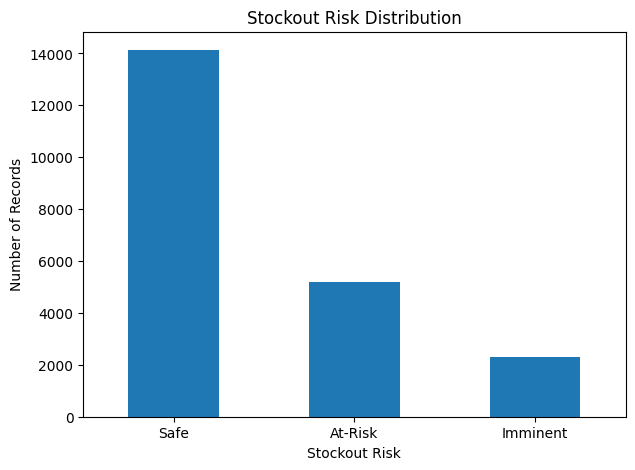

In [ ]:
import matplotlib.pyplot as plt

df["stockout_risk"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

##  Stockout Risk by Festival Week

In [ ]:
festival_risk = pd.crosstab(
    df["is_festival_week"],
    df["stockout_risk"],
    normalize="index"
) * 100

festival_risk

stockout_risk,At-Risk,Imminent,Safe
is_festival_week,,,
N,24.192740,9.511633,66.295628
Y,21.799517,23.309179,54.891304


In [ ]:
imminent_festival = (
    df.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

imminent_festival

,stockout_risk
is_festival_week,
N,9.511633
Y,23.309179


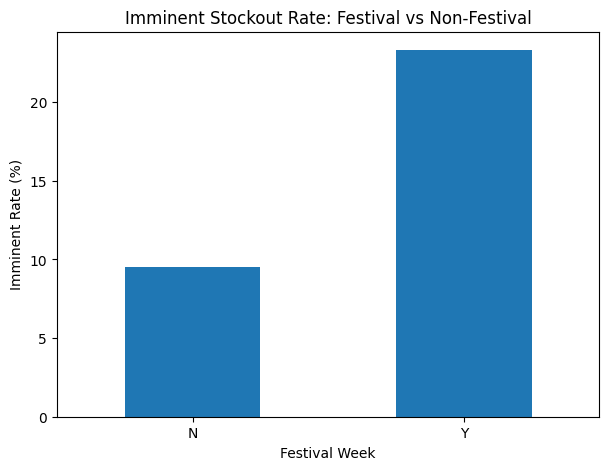

In [ ]:
imminent_festival.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate: Festival vs Non-Festival")
plt.xlabel("Festival Week")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

##  Stockout Risk by Supplier Reliability

In [ ]:
df["supplier_reliability_category"] = pd.cut(
    df["reliability_score"],
    bins=[0, 0.75, 0.85, 1],
    labels=["Low", "Mid", "High"],
    include_lowest=True
)

In [ ]:
supplier_risk = pd.crosstab(
    df["supplier_reliability_category"],
    df["stockout_risk"],
    normalize="index"
) * 100

supplier_risk

stockout_risk,At-Risk,Imminent,Safe
supplier_reliability_category,,,
Low,21.628788,13.074495,65.296717
Mid,17.569444,3.263889,79.166667
High,34.884259,3.819444,61.296296


In [ ]:
imminent_supplier = (
    df.groupby("supplier_reliability_category", observed=True)["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

imminent_supplier

,stockout_risk
supplier_reliability_category,
Low,13.074495
Mid,3.263889
High,3.819444


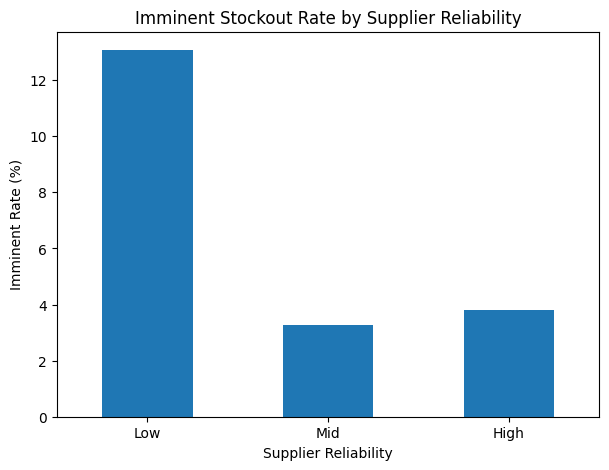

In [ ]:
imminent_supplier.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate by Supplier Reliability")
plt.xlabel("Supplier Reliability")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

##  Stockout Risk by Perishability

In [ ]:
perishable_risk = pd.crosstab(
    df["is_perishable"],
    df["stockout_risk"],
    normalize="index"
) * 100

perishable_risk

stockout_risk,At-Risk,Imminent,Safe
is_perishable,,,
N,24.641813,9.298246,66.059942
Y,22.916667,12.765152,64.318182


In [ ]:
imminent_perishable = (
    df.groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

imminent_perishable

,stockout_risk
is_perishable,
N,9.298246
Y,12.765152


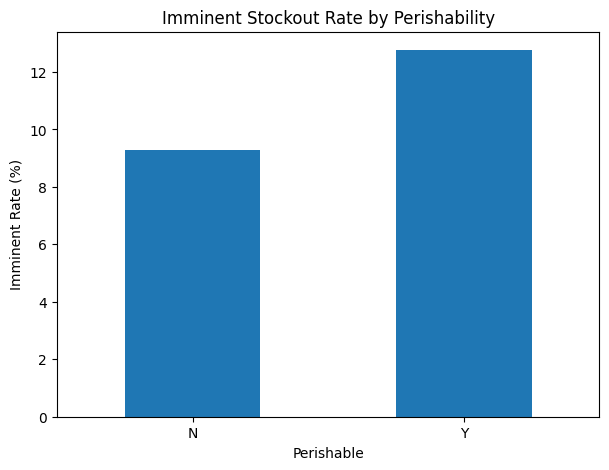

In [ ]:
imminent_perishable.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate by Perishability")
plt.xlabel("Perishable")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

##  Inventory Characteristics and Stockout Risk

In [ ]:
df.groupby("stockout_risk")[[
    "closing_stock",
    "sales_velocity_7d",
    "days_of_cover"
]].mean()

,closing_stock,sales_velocity_7d,days_of_cover
stockout_risk,,,
At-Risk,74.320748,18.294383,4.051568
Imminent,34.728515,17.536386,1.947157
Safe,159.537648,15.969428,10.636469


In [ ]:
df.groupby("stockout_risk")[[
    "closing_stock",
    "sales_velocity_7d",
    "days_of_cover"
]].agg(["mean", "median", "min", "max"])

closing_stock                     sales_velocity_7d         \
                       mean median  min     max              mean median   
stockout_risk                                                              
At-Risk           74.320748   45.8  1.0   651.9         18.294383  12.00   
Imminent          34.728515   15.2  0.0   418.4         17.536386  11.43   
Safe             159.537648  102.3  3.6  1091.6         15.969428  10.71   

                            days_of_cover                      
                min     max          mean median  min     max  
stockout_risk                                                  
At-Risk        0.75  108.14      4.051568   3.82  1.0    8.80  
Imminent       1.00  117.57      1.947157   1.72  0.0    7.88  
Safe           0.00  100.99     10.636469  10.05  4.0  134.85

##  Days of Cover by Stockout Risk

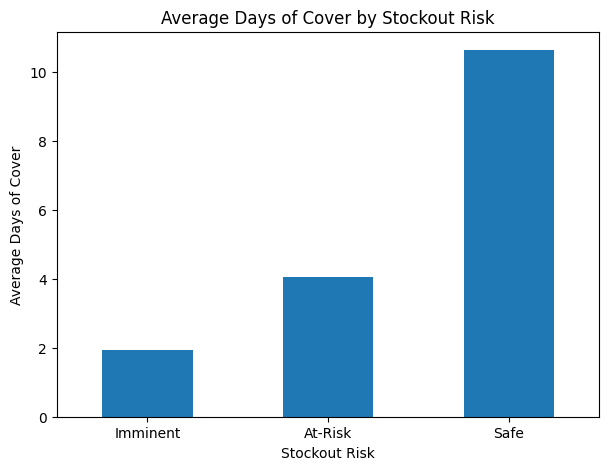

In [ ]:
df.groupby("stockout_risk")["days_of_cover"].mean().sort_values().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Days of Cover by Stockout Risk")
plt.xlabel("Stockout Risk")
plt.ylabel("Average Days of Cover")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.groupby("stockout_risk")["days_of_cover"].median().sort_values()

,days_of_cover
stockout_risk,
Imminent,1.72
At-Risk,3.82
Safe,10.05


##  Stockout Risk by Product Category

In [ ]:
if 'category' not in df.columns:
    df = df.merge(skus[['sku_id', 'category']], on='sku_id', how='left')

category_risk = pd.crosstab(
    df["category"],
    df["stockout_risk"],
    normalize="index"
) * 100

category_risk

stockout_risk,At-Risk,Imminent,Safe
category,,,
Bakery,26.342593,26.111111,47.546296
Beverages,22.083333,14.548611,63.368056
Dairy,14.484127,7.539683,77.976190
Fruits & Vegetables,27.191358,7.932099,64.876543
Home Care,20.601852,8.518519,70.879630
Personal Care,19.166667,6.785714,74.047619
Snacks,28.981481,10.185185,60.833333
Staples,30.138889,5.833333,64.027778


In [ ]:
imminent_category = (
    df.groupby("category")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .sort_values(ascending=False)
)

imminent_category

,stockout_risk
category,
Bakery,26.111111
Beverages,14.548611
Snacks,10.185185
Home Care,8.518519
Fruits & Vegetables,7.932099
Dairy,7.539683
Personal Care,6.785714
Staples,5.833333


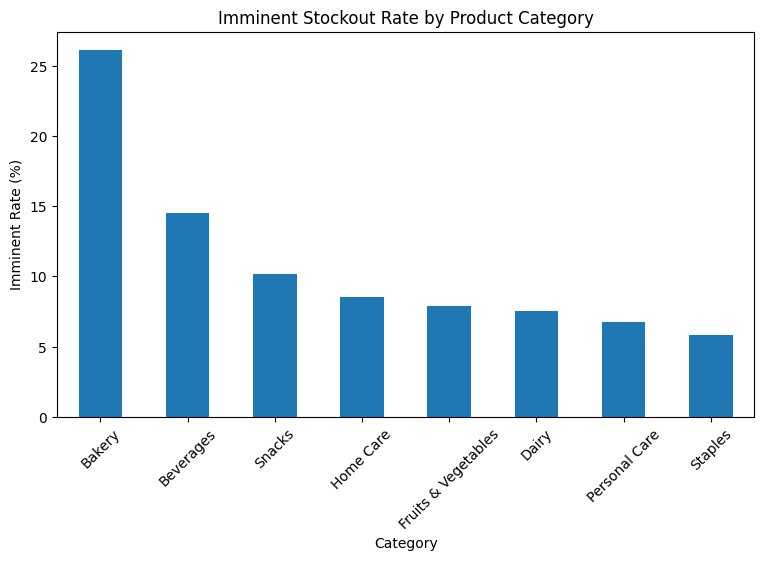

In [ ]:
imminent_category.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Imminent Stockout Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=45)
plt.show()

##  Feature Engineering

### Reorder Gap

In [ ]:
df["reorder_gap"] = df["reorder_point"] - df["closing_stock"]

In [ ]:
df[[
    "reorder_point",
    "closing_stock",
    "reorder_gap"
]].head()

,reorder_point,closing_stock,reorder_gap
0,36.4,144.9,-108.5
1,36.4,134.9,-98.5
2,36.4,119.9,-83.5
3,36.4,109.9,-73.5
4,36.4,100.9,-64.5


##  Days of Cover Ratio

In [ ]:
df["days_of_cover_ratio"] = (
    df["days_of_cover"] / df["lead_time_days_expected"]
)

df[[
    "days_of_cover",
    "lead_time_days_expected",
    "days_of_cover_ratio"
]].head()

,days_of_cover,lead_time_days_expected,days_of_cover_ratio
0,9.66,1,9.66
1,10.79,1,10.79
2,8.99,1,8.99
3,8.79,1,8.79
4,8.55,1,8.55


##  Clean Supplier Reliability

In [ ]:
df["supplier_reliability_clean"] = df["reliability_score"]

df[[
    "reliability_score",
    "supplier_reliability_clean"
]].head()

,reliability_score,supplier_reliability_clean
0,0.83,0.83
1,0.83,0.83
2,0.83,0.83
3,0.83,0.83
4,0.83,0.83


##  Recent Reorder Feature

In [ ]:
df = df.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)

df["previous_reorder_date"] = (
    df["date"]
    .where(df["reorder_placed"] == "Y")
    .groupby([df["store_id"], df["sku_id"]])
    .ffill()
    .groupby([df["store_id"], df["sku_id"]])
    .shift(1)
)

df["is_recent_reorder"] = (
    (df["date"] - df["previous_reorder_date"]).dt.days <= 3
).astype(int)

In [ ]:
df[[
    "store_id",
    "sku_id",
    "date",
    "reorder_placed",
    "previous_reorder_date",
    "is_recent_reorder"
]].head(20)

,store_id,sku_id,date,reorder_placed,previous_reorder_date,is_recent_reorder
0,ST01,SKU001,2026-10-01,N,NaT,0
1,ST01,SKU001,2026-10-02,N,NaT,0
2,ST01,SKU001,2026-10-03,N,NaT,0
3,ST01,SKU001,2026-10-04,N,NaT,0
4,ST01,SKU001,2026-10-05,N,NaT,0
5,ST01,SKU001,2026-10-06,N,NaT,0
6,ST01,SKU001,2026-10-07,N,NaT,0
7,ST01,SKU001,2026-10-08,N,NaT,0
8,ST01,SKU001,2026-10-09,N,NaT,0
9,ST01,SKU001,2026-10-10,N,NaT,0


##  Category Encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=["category"],
    prefix="category",
    dtype=int
)

[col for col in df.columns if col.startswith("category_")]

['category_Bakery',
 'category_Beverages',
 'category_Dairy',
 'category_Fruits & Vegetables',
 'category_Home Care',
 'category_Personal Care',
 'category_Snacks',
 'category_Staples']

##  Temporal Features

In [ ]:
df["day_of_month"] = df["date"].dt.day

In [ ]:
festival_start = pd.Timestamp("2026-10-22")

df["days_since_festival_start"] = (
    df["date"] - festival_start
).dt.days

In [ ]:
df[[
    "date",
    "day_of_month",
    "days_since_festival_start"
]].drop_duplicates().sort_values("date").head(25)

,date,day_of_month,days_since_festival_start
0,2026-10-01,1,-21
1,2026-10-02,2,-20
2,2026-10-03,3,-19
3,2026-10-04,4,-18
4,2026-10-05,5,-17
5,2026-10-06,6,-16
6,2026-10-07,7,-15
7,2026-10-08,8,-14
8,2026-10-09,9,-13
9,2026-10-10,10,-12


# Preparing the Dataset for Machine Learning

In [ ]:
df = df.drop(columns=["previous_reorder_date"])

In [ ]:
print("Target column:", "stockout_risk")
print(df["stockout_risk"].value_counts())

Target column: stockout_risk
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [ ]:
train_df = df[df["date"] <= "2026-10-23"].copy()
test_df = df[df["date"] >= "2026-10-24"].copy()

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)

Training data: (16560, 55)
Testing data : (5040, 55)


In [ ]:
X_train = train_df.drop(columns=["stockout_risk", "date"])
y_train = train_df["stockout_risk"]

X_test = test_df.drop(columns=["stockout_risk", "date"])
y_test = test_df["stockout_risk"]

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (16560, 53)
y_train: (16560,)
X_test : (5040, 53)
y_test : (5040,)


# Baseline Model

In [ ]:
majority_class = y_train.mode()[0]

print("Majority class:", majority_class)

Majority class: Safe


In [ ]:
y_pred_baseline = [majority_class] * len(y_test)

In [ ]:
from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Accuracy (%):", baseline_accuracy * 100)

Baseline Accuracy: 0.6228174603174603
Baseline Accuracy (%): 62.28174603174603


##  Multinomial Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial"
    ))
])

In [ ]:
id_columns = [
    "store_id",
    "sku_id",
    "supplier_id"
]

X_train = X_train.drop(columns=id_columns)
X_test = X_test.drop(columns=id_columns)

In [ ]:
X_train.select_dtypes(include="object").columns.tolist()

['supplier_id_x',
 'reorder_placed',
 'is_festival_week',
 'city',
 'city_display',
 'city_tier',
 'store_size',
 'sku_name',
 'is_perishable',
 'festive_relevant',
 'popularity_tier',
 'supplier_id_y',
 'supplier_name',
 'categories_supplied',
 'event_name',
 'event_type']

In [ ]:
drop_columns = [
    "supplier_id_x",
    "supplier_id_y",
    "city",
    "city_display",
    "city_tier",
    "sku_name",
    "supplier_name",
    "categories_supplied",
    "event_name"
]

X_train = X_train.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)

In [ ]:
categorical_columns = [
    "reorder_placed",
    "is_festival_week",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "store_size",
    "event_type"
]

X_train = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=int
)

In [ ]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [ ]:
print("Remaining text columns:")
print(X_train.select_dtypes(include="object").columns.tolist())

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Remaining text columns:
[]

X_train shape: (16560, 51)
X_test shape : (5040, 51)


In [ ]:
X_train = X_train.drop(columns=["supplier_reliability_category"])
X_test = X_test.drop(columns=["supplier_reliability_category"])

In [ ]:
print(X_train.select_dtypes(include="object").columns.tolist())

[]


In [ ]:
print(X_train.dtypes[X_train.dtypes == "category"])

Series([], dtype: object)


In [ ]:
X_train = X_train.drop(columns=["supplier_reliability_category"], errors="ignore")
X_test = X_test.drop(columns=["supplier_reliability_category"], errors="ignore")

In [ ]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nRemaining text columns:")
print(X_train.select_dtypes(include="object").columns.tolist())

X_train: (16560, 50)
X_test : (5040, 50)

Remaining text columns:
[]


In [ ]:
missing_train = X_train.isnull().sum()

missing_train[missing_train > 0].sort_values(ascending=False)

,0
lead_time_days_actual,15191


In [ ]:
X_train = X_train.drop(columns=["lead_time_days_actual"])
X_test = X_test.drop(columns=["lead_time_days_actual"])

In [ ]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [ ]:
 logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial'))])

In [ ]:
y_pred_logistic = logistic_model.predict(X_test)

print(y_pred_logistic[:20])

['At-Risk' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Imminent' 'Imminent'
 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'At-Risk' 'At-Risk'
 'At-Risk' 'At-Risk']


##  Logistic Regression Evaluation

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

     At-Risk       0.89      0.81      0.85      1126
    Imminent       0.84      0.85      0.84       775
        Safe       0.97      1.00      0.99      3139

    accuracy                           0.93      5040
   macro avg       0.90      0.89      0.89      5040
weighted avg       0.93      0.93      0.93      5040



In [ ]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100)

Logistic Regression Accuracy: 0.9347222222222222
Logistic Regression Accuracy (%): 93.47222222222223


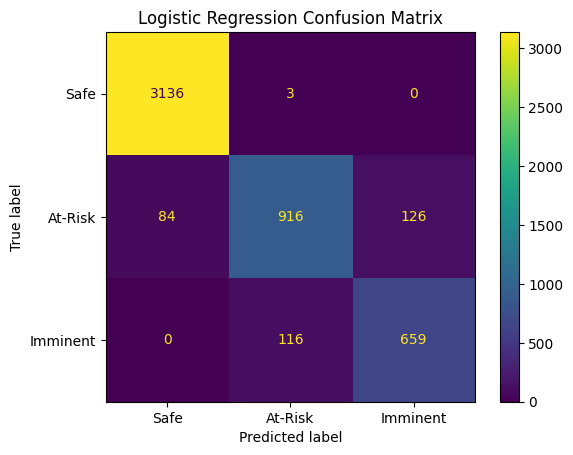

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Safe", "At-Risk", "Imminent"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "At-Risk", "Imminent"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

##  Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print(y_pred_rf[:20])

['At-Risk' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Imminent' 'Imminent'
 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'Safe' 'At-Risk' 'At-Risk'
 'At-Risk' 'At-Risk']


## Random Forest Evaluation

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

     At-Risk       0.82      0.94      0.88      1126
    Imminent       0.90      0.71      0.80       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.94      5040
   macro avg       0.91      0.89      0.89      5040
weighted avg       0.94      0.94      0.94      5040



In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.9424603174603174
Random Forest Accuracy (%): 94.24603174603175


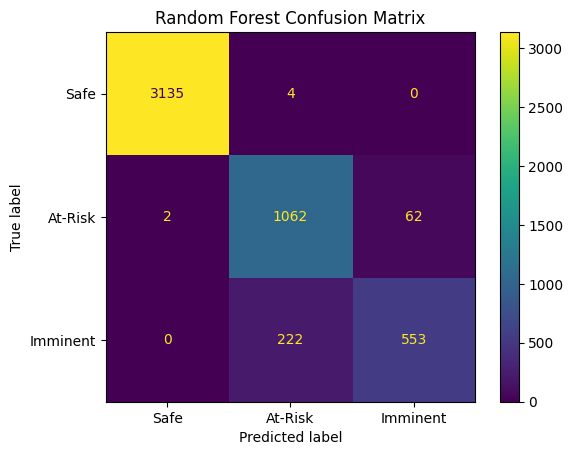

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Safe", "At-Risk", "Imminent"]
)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Safe", "At-Risk", "Imminent"]
)

disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

## Model Comparison

In [ ]:
from sklearn.metrics import recall_score

labels = ["Safe", "At-Risk", "Imminent"]

baseline_recalls = recall_score(
    y_test,
    y_pred_baseline,
    labels=labels,
    average=None,
    zero_division=0
)

logistic_recalls = recall_score(
    y_test,
    y_pred_logistic,
    labels=labels,
    average=None,
    zero_division=0
)

rf_recalls = recall_score(
    y_test,
    y_pred_rf,
    labels=labels,
    average=None,
    zero_division=0
)

# Imminent is the third class
baseline_imminent_recall = baseline_recalls[2]
logistic_imminent_recall = logistic_recalls[2]
rf_imminent_recall = rf_recalls[2]

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        rf_accuracy
    ],
    "Imminent Recall": [
        baseline_imminent_recall,
        logistic_imminent_recall,
        rf_imminent_recall
    ]
})

comparison_display = comparison.copy()

comparison_display["Accuracy"] = (
    comparison_display["Accuracy"] * 100
).round(2)

comparison_display["Imminent Recall"] = (
    comparison_display["Imminent Recall"] * 100
).round(2)

comparison_display

,Model,Accuracy,Imminent Recall
0,Majority Baseline,62.28,0.00
1,Logistic Regression,93.47,85.03
2,Random Forest,94.25,71.35


## Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,days_of_cover,0.242159
19,days_of_cover_ratio,0.225134
18,reorder_gap,0.191420
3,closing_stock,0.045387
33,reorder_placed_Y,0.023597
6,sales_velocity_7d,0.022911
0,opening_stock,0.022183
32,reorder_placed_N,0.019829
4,reorder_point,0.019376
21,is_recent_reorder,0.016502


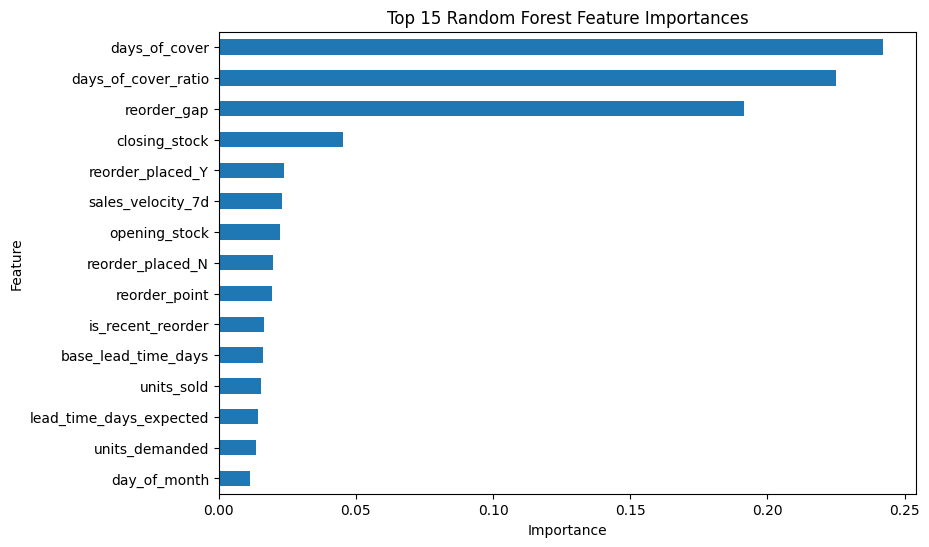

In [ ]:
feature_importance.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

##  Final Model Comparison

In [ ]:
final_comparison = comparison_display.sort_values(
    "Imminent Recall",
    ascending=False
)

final_comparison

,Model,Accuracy,Imminent Recall
1,Logistic Regression,93.47,85.03
2,Random Forest,94.25,71.35
0,Majority Baseline,62.28,0.00


In [ ]:
best_model = final_comparison.iloc[0]["Model"]

print("Best model based on Imminent Recall:", best_model)

Best model based on Imminent Recall: Logistic Regression


## Final Conclusion

This project developed a supervised machine learning classification system to predict daily inventory stockout risk for QuickCart stores and SKUs.

The dataset was assembled by combining store, SKU, supplier, event, and daily inventory information. Data-quality issues were handled before modeling, and the suggested feature-engineering techniques were applied, including reorder gap, days-of-cover ratio, supplier reliability, recent reorder information, category encoding, and temporal features.

A time-based train/test split was used to reduce information leakage between repeated store-SKU observations.

The majority-class baseline, Logistic Regression, and Random Forest models were evaluated using classification metrics. Since the Imminent class represents potential stockouts, recall for this class was given particular importance.

The final model should be selected based primarily on its ability to identify Imminent cases while maintaining reasonable overall classification performance.

Random Forest feature importance was also examined to identify the inventory, demand, supplier, and temporal factors that contributed most to the model's predictions.